## Part A: Digit Classifier

### 1. Load digits dataset and Scale features

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset loaded and features scaled.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Dataset loaded and features scaled.
X_train_scaled shape: (1437, 64)
X_test_scaled shape: (360, 64)


### 2. Train SVM(RBF) with GridSearchCV on C and gamma

In [2]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Initialize the SVM classifier
svm = SVC()

# Initialize GridSearchCV with the SVM classifier and parameter grid
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_svm.fit(X_train_scaled, y_train)

# Get the best SVM model
best_svm = grid_search_svm.best_estimator_

print(f"Best SVM parameters: {grid_search_svm.best_params_}")
print(f"Best SVM accuracy on training set (from GridSearchCV): {grid_search_svm.best_score_:.4f}")

# Evaluate the best SVM model on the test set
svm_test_accuracy = best_svm.score(X_test_scaled, y_test)
print(f"Best SVM accuracy on test set: {svm_test_accuracy:.4f}")

Best SVM parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM accuracy on training set (from GridSearchCV): 0.9812
Best SVM accuracy on test set: 0.9806


### 3. Train KNN with optimal K

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Define a range of K values to test
param_grid_knn = {
    'n_neighbors': range(1, 10)
}

# Initialize the KNN classifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV with the KNN classifier and parameter grid
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_knn.fit(X_train_scaled, y_train)

# Get the best KNN model
best_knn = grid_search_knn.best_estimator_

print(f"Best KNN parameters: {grid_search_knn.best_params_}")
print(f"Best KNN accuracy on training set (from GridSearchCV): {grid_search_knn.best_score_:.4f}")

# Evaluate the best KNN model on the test set
knn_test_accuracy = best_knn.score(X_test_scaled, y_test)
print(f"Best KNN accuracy on test set: {knn_test_accuracy:.4f}")

Best KNN parameters: {'n_neighbors': 3}
Best KNN accuracy on training set (from GridSearchCV): 0.9749
Best KNN accuracy on test set: 0.9694


### 4. Compare accuracy, confusion matrices, and per-class F1 scores


--- Model Comparison ---

### SVM Model Evaluation

SVM Confusion Matrix:

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  1  0  0  0  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


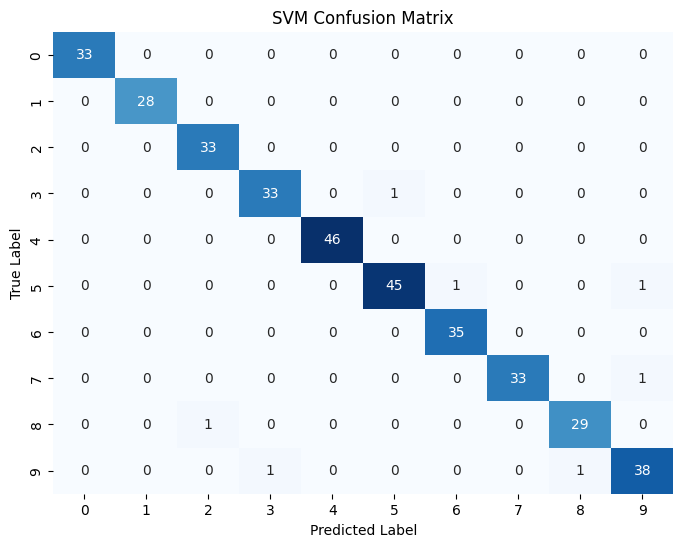


SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


### KNN Model Evaluation

KNN Confusion Matrix:

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  1 32  0  0  0  0  0  0  0]
 [ 0  0  1 33  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  

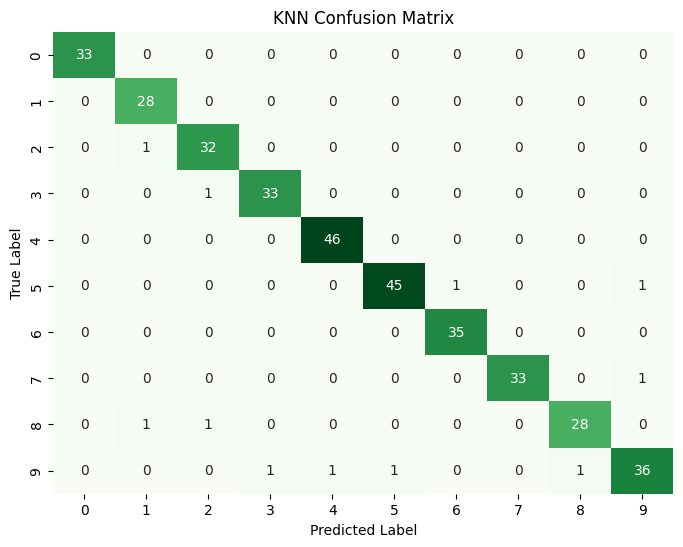


KNN Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.94      0.97      0.96        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


--- Overall Accuracy Comparison ---
SVM Test Accuracy: 0.9806
KNN Test Accuracy: 0.9694

--- Identifying Most Confused Digits ---

Top 5 most commonly confused digits for SVM:
  True: 5, Predicted: 9, Count: 1
 

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Model Comparison ---\n")

# --- SVM Model Evaluation ---
print("### SVM Model Evaluation")
svm_predictions = best_svm.predict(X_test_scaled)

# Confusion Matrix for SVM
svm_cm = confusion_matrix(y_test, svm_predictions)
print("\nSVM Confusion Matrix:\n")
print(svm_cm)

# Plotting Confusion Matrix for SVM
plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report for SVM (includes F1-score per class)
print("\nSVM Classification Report:\n")
svm_report = classification_report(y_test, svm_predictions, output_dict=True)
print(classification_report(y_test, svm_predictions))

# --- KNN Model Evaluation ---
print("\n### KNN Model Evaluation")
knn_predictions = best_knn.predict(X_test_scaled)

# Confusion Matrix for KNN
knn_cm = confusion_matrix(y_test, knn_predictions)
print("\nKNN Confusion Matrix:\n")
print(knn_cm)

# Plotting Confusion Matrix for KNN
plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report for KNN (includes F1-score per class)
print("\nKNN Classification Report:\n")
knn_report = classification_report(y_test, knn_predictions, output_dict=True)
print(classification_report(y_test, knn_predictions))

# --- Overall Accuracy Comparison ---
print("\n--- Overall Accuracy Comparison ---")
print(f"SVM Test Accuracy: {svm_test_accuracy:.4f}")
print(f"KNN Test Accuracy: {knn_test_accuracy:.4f}")

# --- Identifying Most Confused Digits ---
print("\n--- Identifying Most Confused Digits ---")

def get_most_confused_digits(confusion_matrix_data, model_name):
    misclassifications = []
    for i in range(len(confusion_matrix_data)):
        for j in range(len(confusion_matrix_data[i])):
            if i != j:
                misclassifications.append({
                    'true_label': i,
                    'predicted_label': j,
                    'count': confusion_matrix_data[i, j]
                })

    misclassifications_df = pd.DataFrame(misclassifications)
    misclassifications_df = misclassifications_df.sort_values(by='count', ascending=False)

    print(f"\nTop 5 most commonly confused digits for {model_name}:")
    for index, row in misclassifications_df.head(5).iterrows():
        if row['count'] > 0:
            print(f"  True: {int(row['true_label'])}, Predicted: {int(row['predicted_label'])}, Count: {int(row['count'])}")
        else:
            print(f"  No misclassifications found beyond this point for {model_name}.")
            break

get_most_confused_digits(svm_cm, 'SVM')
get_most_confused_digits(knn_cm, 'KNN')


### 5. Per-class F1-score Comparison

In [5]:
import pandas as pd

# Extract F1-scores for each class from SVM report
svm_f1_scores = {class_label: metrics['f1-score'] for class_label, metrics in svm_report.items() if class_label.isdigit()}

# Extract F1-scores for each class from KNN report
knn_f1_scores = {class_label: metrics['f1-score'] for class_label, metrics in knn_report.items() if class_label.isdigit()}

# Create a DataFrame for comparison
f1_comparison_df = pd.DataFrame({
    'Class': sorted(svm_f1_scores.keys()),
    'SVM F1-Score': [svm_f1_scores[str(i)] for i in range(10)],
    'KNN F1-Score': [knn_f1_scores[str(i)] for i in range(10)]
})

print("\n--- Per-Class F1-Score Comparison ---")
display(f1_comparison_df)



--- Per-Class F1-Score Comparison ---


,Class,SVM F1-Score,KNN F1-Score
0,0,1.000000,1.000000
1,1,1.000000,0.965517
2,2,0.985075,0.955224
3,3,0.970588,0.970588
4,4,1.000000,0.989247
5,5,0.967742,0.967742
6,6,0.985915,0.985915
7,7,0.985075,0.985075
8,8,0.966667,0.949153
9,9,0.950000,0.923077
